In [9]:
# ============================================================
# EXPERIMENT 6
# RNN vs LSTM vs GRU + CNN-RNN + Seq2Seq
# ============================================================

!pip -q install scikit-learn seaborn opencv-python

import os
import time
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Output folders
os.makedirs("plots", exist_ok=True)
os.makedirs("models", exist_ok=True)

# EPS configuration
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
import os
import zipfile

zip_path = "/content/human+activity+recognition+using+smartphones.zip"

print("ZIP exists:", os.path.exists(zip_path))

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Extraction completed.")

ZIP exists: True
Extraction completed.


In [11]:
import os
import shutil
import zipfile

zip_path = "/content/UCI HAR Dataset.zip"
extract_path = "/content"

print("ZIP exists:", os.path.exists(zip_path))

# Remove any incomplete extracted folder
dataset_path = "/content/UCI HAR Dataset"

if os.path.exists(dataset_path):
    shutil.rmtree(dataset_path)

# Extract
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")

# Check contents of /content
print("\nContent of /content:")
print(os.listdir("/content"))

ZIP exists: True
Extraction completed.

Content of /content:
['.config', 'human+activity+recognition+using+smartphones.zip', 'UCI HAR Dataset.names', 'models', 'UCI HAR Dataset', 'UCI HAR Dataset.zip', '.ipynb_checkpoints', 'plots', '__MACOSX', 'sample_data']


In [12]:
import os

for root, dirs, files in os.walk("/content"):
    if "body_acc_x_train.txt" in files:
        print("FOUND:")
        print(os.path.join(root, "body_acc_x_train.txt"))

FOUND:
/content/UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt


In [13]:
BASE = "/content/UCI HAR Dataset"

print("Dataset exists:", os.path.exists(BASE))
print("Train exists:", os.path.exists(os.path.join(BASE, "train")))
print("Test exists:", os.path.exists(os.path.join(BASE, "test")))
print(
    "Inertial Signals exists:",
    os.path.exists(os.path.join(BASE, "train", "Inertial Signals"))
)

Dataset exists: True
Train exists: True
Test exists: True
Inertial Signals exists: True


In [14]:
# ============================================================
# LOAD RAW INERTIAL SIGNALS
# ============================================================


channels = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

def load_split(split):
    signal_dir = os.path.join(BASE, split, "Inertial Signals")

    signals = []

    for channel in channels:
        filename = f"{channel}_{split}.txt"
        path = os.path.join(signal_dir, filename)

        data = np.loadtxt(path)

        signals.append(data)

    # Each signal: (N, 128)
    # Stack → (N, 128, 9)
    X = np.stack(signals, axis=-1)

    y_path = os.path.join(BASE, split, f"y_{split}.txt")
    y = np.loadtxt(y_path).astype(int) - 1

    return X, y


X_train_full, y_train_full = load_split("train")
X_test_original, y_test_original = load_split("test")

print("Full training data:", X_train_full.shape)
print("Full test data:", X_test_original.shape)

Full training data: (7352, 128, 9)
Full test data: (2947, 128, 9)


In [15]:
# ============================================================
# SELECT 3000 BALANCED SAMPLES
# ============================================================

SAMPLES_PER_CLASS = 500

selected_indices = []

for class_id in range(6):
    indices = np.where(y_train_full == class_id)[0]

    np.random.shuffle(indices)

    selected_indices.extend(indices[:SAMPLES_PER_CLASS])

selected_indices = np.array(selected_indices)

X_selected = X_train_full[selected_indices]
y_selected = y_train_full[selected_indices]

print("Selected data:", X_selected.shape)
print("Labels:", y_selected.shape)

print("\nClass distribution:")
print(pd.Series(y_selected).value_counts().sort_index())

Selected data: (3000, 128, 9)
Labels: (3000,)

Class distribution:
0    500
1    500
2    500
3    500
4    500
5    500
Name: count, dtype: int64


In [16]:
# ============================================================
# 70 / 15 / 15 SPLIT
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_selected,
    y_selected,
    test_size=0.30,
    random_state=SEED,
    stratify=y_selected
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)

Training   : (2100, 128, 9)
Validation : (450, 128, 9)
Testing    : (450, 128, 9)


In [17]:
# ============================================================
# NORMALIZATION
# ============================================================

N, T, F = X_train.shape

scaler = StandardScaler()

# Fit ONLY on training data
X_train_2d = X_train.reshape(-1, F)

scaler.fit(X_train_2d)

def normalize(X):
    shape = X.shape

    X = X.reshape(-1, F)
    X = scaler.transform(X)
    X = X.reshape(shape)

    return X


X_train = normalize(X_train)
X_val = normalize(X_val)
X_test = normalize(X_test)

print("After normalization:")
print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)

After normalization:
Training   : (2100, 128, 9)
Validation : (450, 128, 9)
Testing    : (450, 128, 9)


In [18]:
# ============================================================
# CLASS NAMES
# ============================================================

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

NUM_CLASSES = 6

print("Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Classes:
0 : WALKING
1 : WALKING_UPSTAIRS
2 : WALKING_DOWNSTAIRS
3 : SITTING
4 : STANDING
5 : LAYING


In [19]:
# ============================================================
# CLASS DISTRIBUTION
# ============================================================

print("Training distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTesting distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training distribution:
0    350
1    350
2    350
3    350
4    350
5    350
Name: count, dtype: int64

Validation distribution:
0    75
1    75
2    75
3    75
4    75
5    75
Name: count, dtype: int64

Testing distribution:
0    75
1    75
2    75
3    75
4    75
5    75
Name: count, dtype: int64


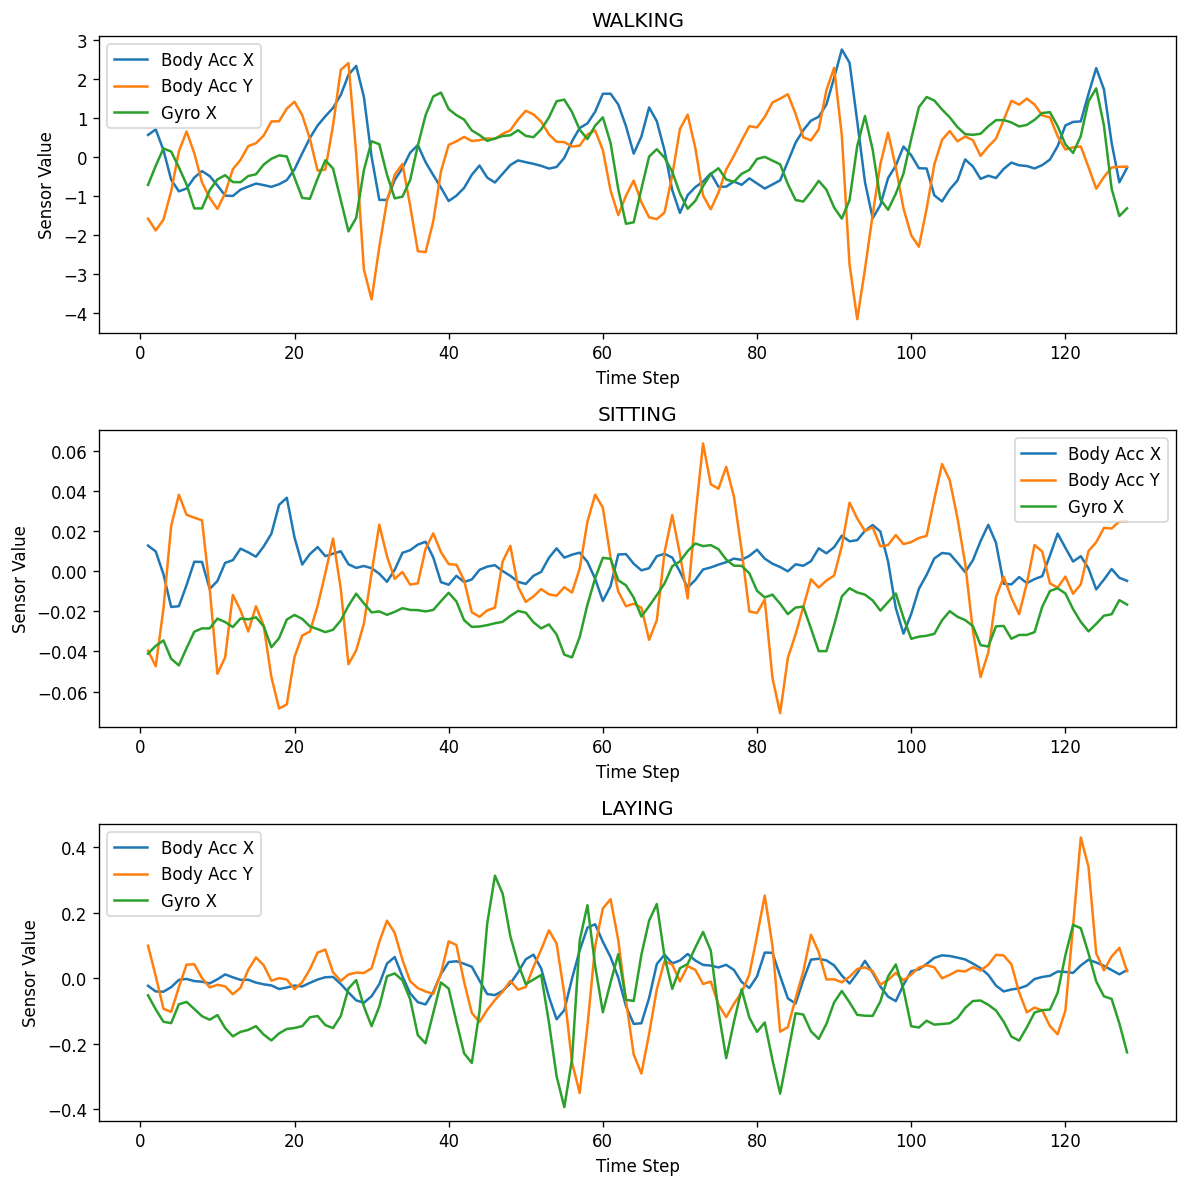

In [20]:
# ============================================================
# PLOT 1 - TEMPORAL SENSOR SIGNALS
# ============================================================

representative_classes = [0, 3, 5]  # Walking, Sitting, Laying
channel_indices = [0, 1, 3]

channel_names = [
    "Body Acc X",
    "Body Acc Y",
    "Body Acc Z",
    "Gyro X",
    "Gyro Y",
    "Gyro Z",
    "Total Acc X",
    "Total Acc Y",
    "Total Acc Z"
]

fig, axes = plt.subplots(
    len(representative_classes),
    1,
    figsize=(10, 10)
)

for row, class_id in enumerate(representative_classes):

    idx = np.where(y_train == class_id)[0][0]

    for ch in channel_indices:
        axes[row].plot(
            range(1, 129),
            X_train[idx, :, ch],
            label=channel_names[ch]
        )

    axes[row].set_title(class_names[class_id])
    axes[row].set_xlabel("Time Step")
    axes[row].set_ylabel("Sensor Value")
    axes[row].legend()

plt.tight_layout()

plt.savefig(
    "plots/plot1_sensor_signal.eps",
    format="eps",
    bbox_inches="tight"
)

plt.show()

In [21]:
# ============================================================
# NUMERICAL RNN EXERCISE
# ============================================================

x = [0.5, 0.7, 0.2]

h = 0
Wx = 0.5
Wh = 0.8
b = 0.1

for i, xt in enumerate(x):

    h = np.tanh(Wx * xt + Wh * h + b)

    print(f"h{i+1} =", h)

h1 = 0.3363755443363322
h2 = 0.6163517827505027
h3 = 0.5999579155496113


In [22]:
# ============================================================
# MODEL BUILDER
# ============================================================

def build_model(model_type):

    model = tf.keras.Sequential()

    model.add(
        tf.keras.layers.Input(
            shape=(128, 9)
        )
    )

    if model_type == "RNN":

        model.add(
            tf.keras.layers.SimpleRNN(
                32
            )
        )

    elif model_type == "LSTM":

        model.add(
            tf.keras.layers.LSTM(
                32
            )
        )

    elif model_type == "GRU":

        model.add(
            tf.keras.layers.GRU(
                32
            )
        )

    model.add(
        tf.keras.layers.Dropout(0.2)
    )

    model.add(
        tf.keras.layers.Dense(
            16,
            activation="relu"
        )
    )

    model.add(
        tf.keras.layers.Dense(
            6,
            activation="softmax"
        )
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [23]:
# ============================================================
# TRAIN RNN / LSTM / GRU
# ============================================================

models = {}
histories = {}
training_times = {}

EPOCHS = 30
BATCH_SIZE = 32

for model_type in ["RNN", "LSTM", "GRU"]:

    print("\n" + "=" * 60)
    print("Training:", model_type)
    print("=" * 60)

    model = build_model(model_type)

    model.summary()

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    end_time = time.time()

    training_time = end_time - start_time

    models[model_type] = model
    histories[model_type] = history
    training_times[model_type] = training_time

    print(
        f"{model_type} training time: "
        f"{training_time:.2f} seconds"
    )


Training: RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3176 - loss: 1.6434 - val_accuracy: 0.5044 - val_loss: 1.4421
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5162 - loss: 1.2635 - val_accuracy: 0.5756 - val_loss: 1.0700
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6086 - loss: 1.0116 - val_accuracy: 0.6267 - val_loss: 0.9128
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6795 - loss: 0.8151 - val_accuracy: 0.7378 - val_loss: 0.6801
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7719 - loss: 0.5840 - val_accuracy: 0.8044 - val_loss: 0.4499
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8148 - loss: 0.4458 - val_accuracy: 0.8444 - val_loss: 0.3975
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8495 - loss: 0.3747 - val_accuracy: 0.9156 - val_loss: 0.3121
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8929 - loss: 0.3069 - val_accuracy: 0.9289 - v

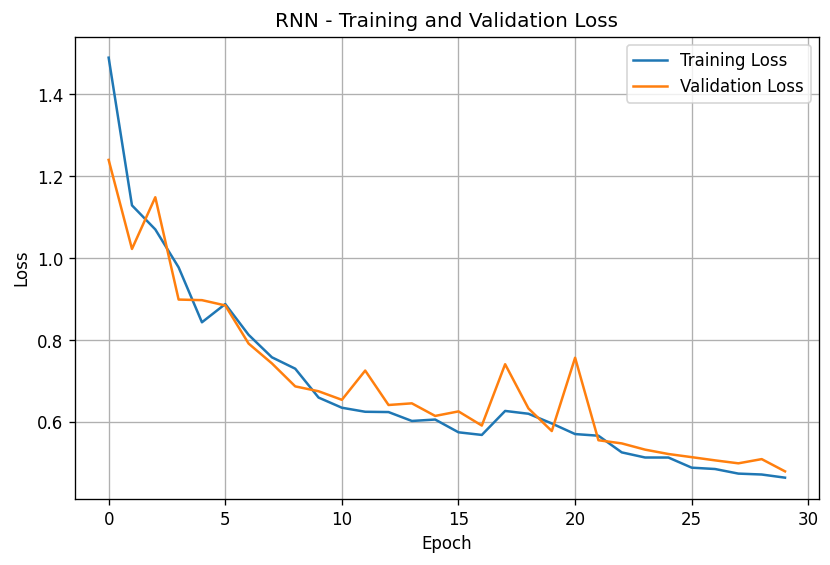

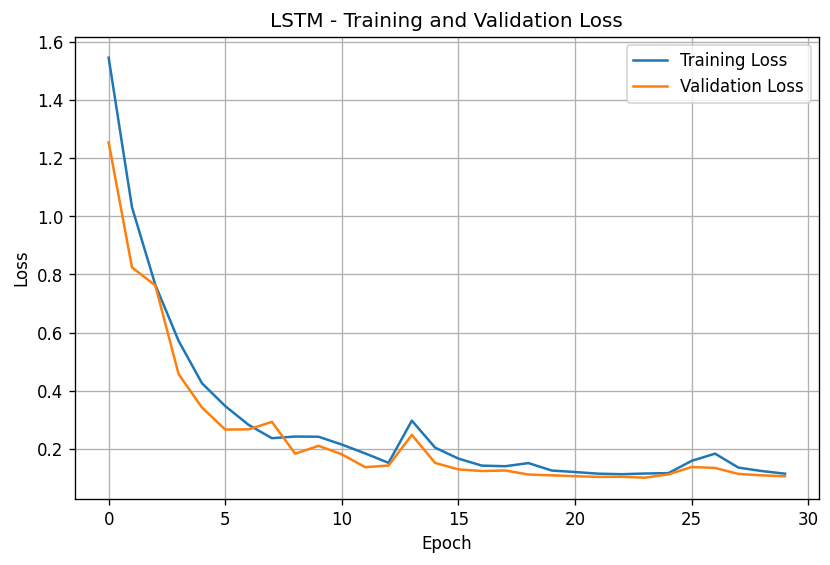

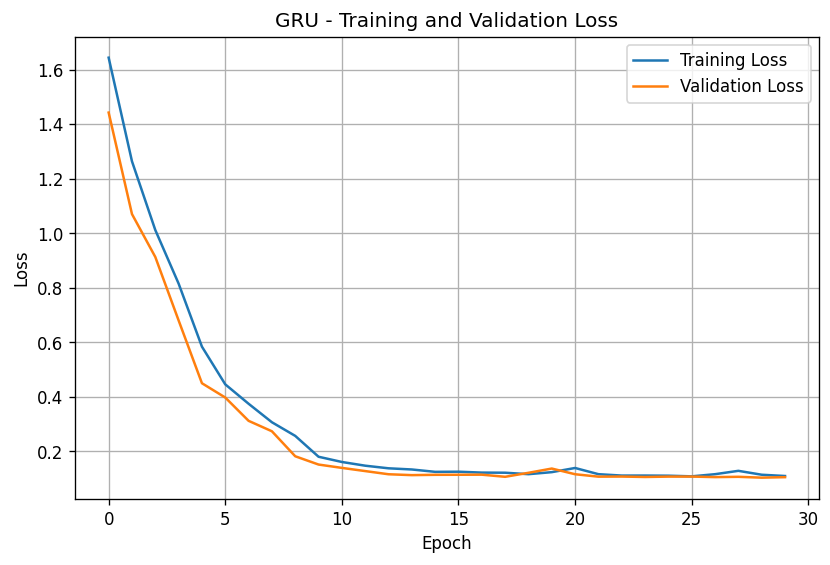

In [24]:
# ============================================================
# PLOT 2 - LOSS CURVES
# ============================================================

for model_type in ["RNN", "LSTM", "GRU"]:

    history = histories[model_type].history

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_type} - Training and Validation Loss")
    plt.legend()
    plt.grid(True)

    plt.savefig(
        f"plots/{model_type.lower()}_loss.eps",
        format="eps",
        bbox_inches="tight"
    )

    plt.show()

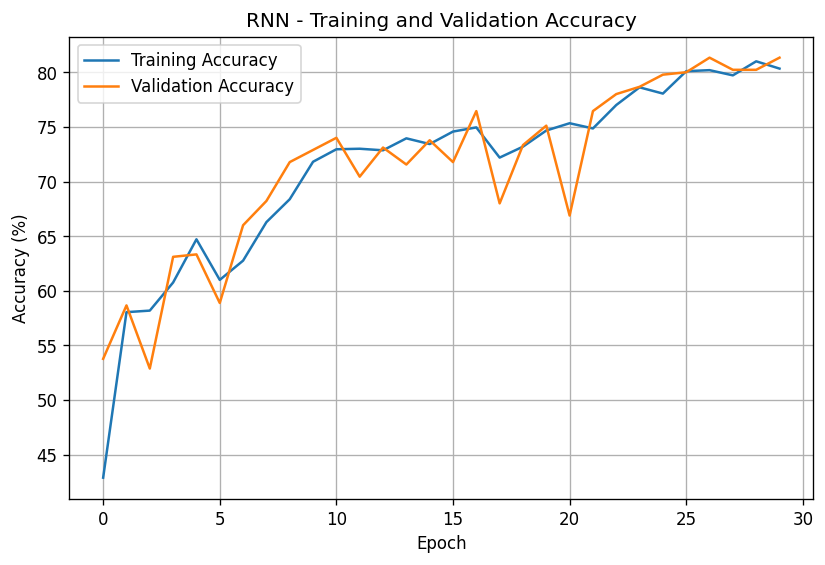

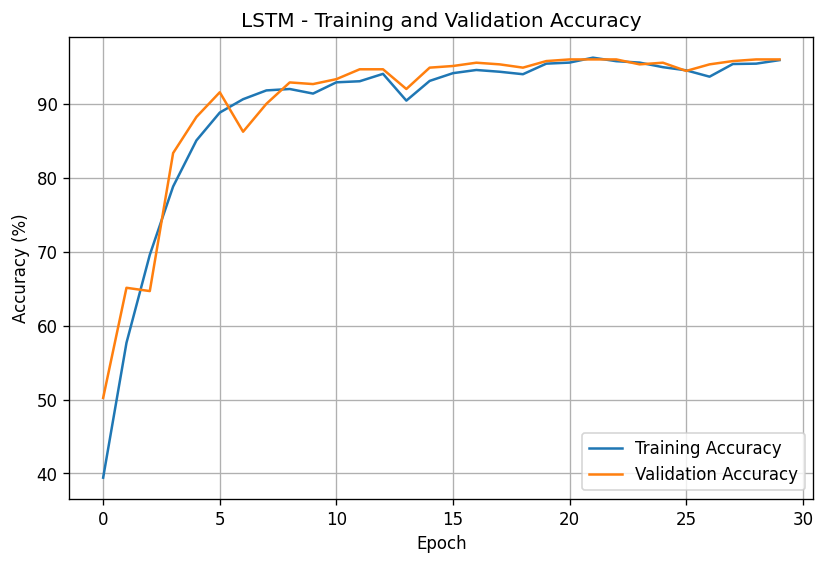

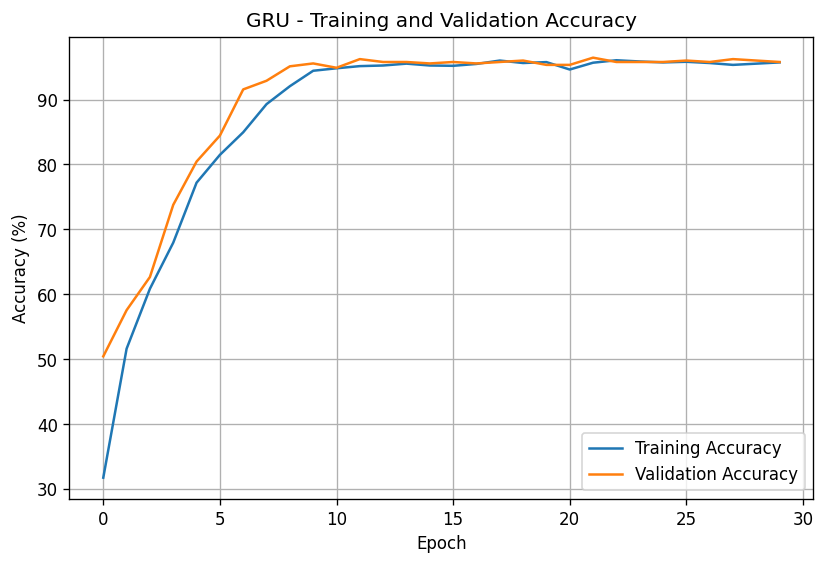

In [25]:
# ============================================================
# PLOT 3 - ACCURACY CURVES
# ============================================================

for model_type in ["RNN", "LSTM", "GRU"]:

    history = histories[model_type].history

    plt.figure(figsize=(8, 5))

    plt.plot(
        np.array(history["accuracy"]) * 100,
        label="Training Accuracy"
    )

    plt.plot(
        np.array(history["val_accuracy"]) * 100,
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{model_type} - Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plt.savefig(
        f"plots/{model_type.lower()}_accuracy.eps",
        format="eps",
        bbox_inches="tight"
    )

    plt.show()

In [26]:
# ============================================================
# MODEL EVALUATION
# ============================================================

results = []

predictions = {}

for model_type, model in models.items():

    probabilities = model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        probabilities,
        axis=1
    )

    predictions[model_type] = y_pred

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    params = model.count_params()

    results.append([
        model_type,
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100,
        params,
        training_times[model_type]
    ])


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy (%)",
        "Macro Precision (%)",
        "Macro Recall (%)",
        "Macro F1 (%)",
        "Parameters",
        "Training Time (s)"
    ]
)

results_df

,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,78.888889,78.797490,78.888889,78.792888,1974,29.888837
1,LSTM,94.666667,94.671645,94.666667,94.666430,6006,27.819974
2,GRU,94.888889,94.858780,94.888889,94.872473,4758,26.169156


In [27]:
# ============================================================
# CLASSIFICATION REPORTS
# ============================================================

for model_type in ["RNN", "LSTM", "GRU"]:

    print("\n")
    print("=" * 70)
    print(model_type)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions[model_type],
            target_names=class_names,
            digits=4
        )
    )



RNN
                    precision    recall  f1-score   support

           WALKING     0.6029    0.5467    0.5734        75
  WALKING_UPSTAIRS     0.7342    0.7733    0.7532        75
WALKING_DOWNSTAIRS     0.6750    0.7200    0.6968        75
           SITTING     0.8400    0.8400    0.8400        75
          STANDING     0.8889    0.8533    0.8707        75
            LAYING     0.9868    1.0000    0.9934        75

          accuracy                         0.7889       450
         macro avg     0.7880    0.7889    0.7879       450
      weighted avg     0.7880    0.7889    0.7879       450



LSTM
                    precision    recall  f1-score   support

           WALKING     0.9868    1.0000    0.9934        75
  WALKING_UPSTAIRS     1.0000    1.0000    1.0000        75
WALKING_DOWNSTAIRS     1.0000    0.9867    0.9933        75
           SITTING     0.8514    0.8400    0.8456        75
          STANDING     0.8421    0.8533    0.8477        75
            LAYING     

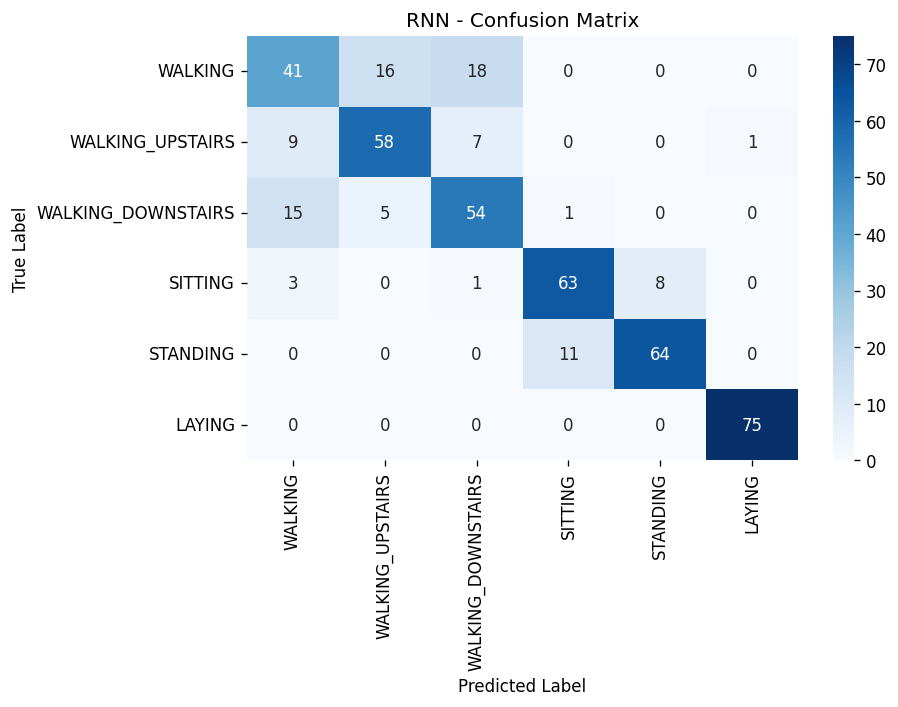

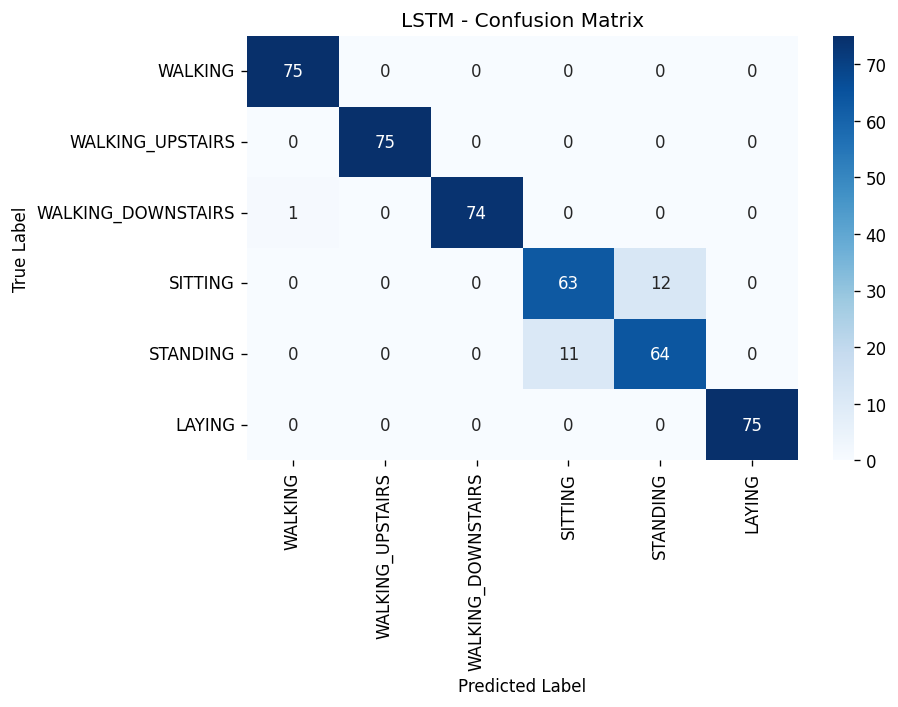

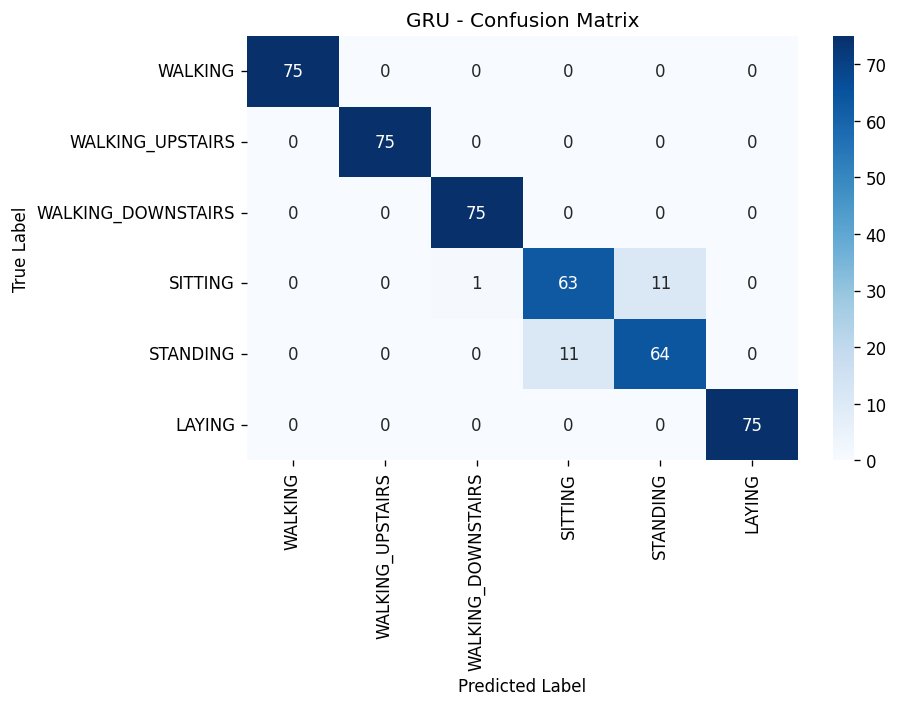

In [28]:
# ============================================================
# PLOT 4 - CONFUSION MATRICES
# ============================================================

confusion_matrices = {}

for model_type in ["RNN", "LSTM", "GRU"]:

    cm = confusion_matrix(
        y_test,
        predictions[model_type]
    )

    confusion_matrices[model_type] = cm

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{model_type} - Confusion Matrix")

    plt.tight_layout()

    plt.savefig(
        f"plots/{model_type.lower()}_confusion_matrix.eps",
        format="eps",
        bbox_inches="tight"
    )

    plt.show()

In [29]:
# ============================================================
# CONFUSION MATRIX ANALYSIS
# ============================================================

for model_type, cm in confusion_matrices.items():

    print("\n" + "=" * 70)
    print(model_type)
    print("=" * 70)

    # Recognition rate
    recognition_rates = np.diag(cm) / cm.sum(axis=1)

    best_class = np.argmax(recognition_rates)

    print(
        "Highest recognition rate:",
        class_names[best_class],
        f"({recognition_rates[best_class] * 100:.2f}%)"
    )

    # Misclassifications
    errors = cm.sum(axis=1) - np.diag(cm)

    worst_class = np.argmax(errors)

    print(
        "Largest number of misclassifications:",
        class_names[worst_class],
        f"({errors[worst_class]} errors)"
    )

    # Most confused pair
    cm_copy = cm.copy()

    np.fill_diagonal(cm_copy, 0)

    i, j = np.unravel_index(
        np.argmax(cm_copy),
        cm_copy.shape
    )

    print(
        "Most frequent confusion:",
        class_names[i],
        "→",
        class_names[j],
        f"({cm_copy[i, j]} samples)"
    )


RNN
Highest recognition rate: LAYING (100.00%)
Largest number of misclassifications: WALKING (34 errors)
Most frequent confusion: WALKING → WALKING_DOWNSTAIRS (18 samples)

LSTM
Highest recognition rate: WALKING (100.00%)
Largest number of misclassifications: SITTING (12 errors)
Most frequent confusion: SITTING → STANDING (12 samples)

GRU
Highest recognition rate: WALKING (100.00%)
Largest number of misclassifications: SITTING (12 errors)
Most frequent confusion: SITTING → STANDING (11 samples)


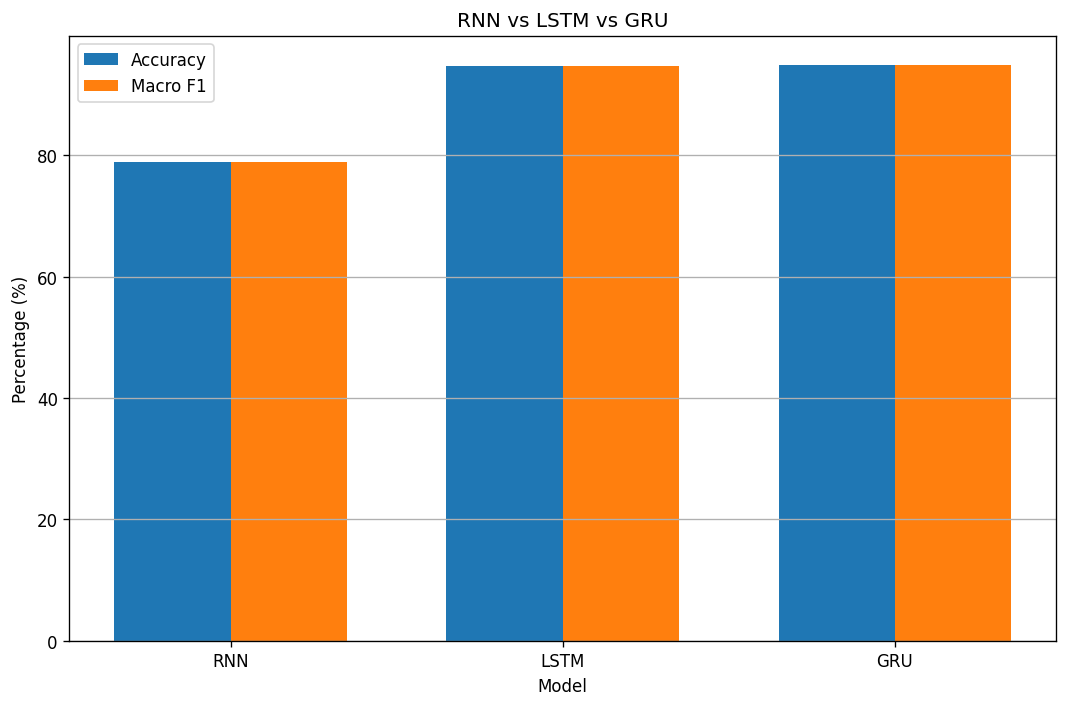

In [30]:
# ============================================================
# PLOT 5 - MODEL PERFORMANCE COMPARISON
# ============================================================

metrics = [
    "Accuracy (%)",
    "Macro F1 (%)"
]

comparison = results_df[
    ["Model"] + metrics
].copy()

x = np.arange(len(comparison["Model"]))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width/2,
    comparison["Accuracy (%)"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    comparison["Macro F1 (%)"],
    width,
    label="Macro F1"
)

plt.xticks(
    x,
    comparison["Model"]
)

plt.ylabel("Percentage (%)")
plt.xlabel("Model")
plt.title("RNN vs LSTM vs GRU")
plt.legend()
plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "plots/plot5_model_comparison.eps",
    format="eps",
    bbox_inches="tight"
)

plt.show()

In [31]:
# ============================================================
# SEQUENCE LENGTH EXPERIMENT
# ============================================================

sequence_lengths = [32, 64, 128]

sequence_results = []

for seq_len in sequence_lengths:

    print("\n" + "=" * 60)
    print("Sequence Length:", seq_len)
    print("=" * 60)

    Xtr = X_train[:, :seq_len, :]
    Xv = X_val[:, :seq_len, :]
    Xt = X_test[:, :seq_len, :]

    for model_type in ["RNN", "LSTM", "GRU"]:

        if model_type == "RNN":
            recurrent_layer = tf.keras.layers.SimpleRNN(32)

        elif model_type == "LSTM":
            recurrent_layer = tf.keras.layers.LSTM(32)

        else:
            recurrent_layer = tf.keras.layers.GRU(32)

        model = tf.keras.Sequential([
            tf.keras.layers.Input(
                shape=(seq_len, 9)
            ),

            recurrent_layer,

            tf.keras.layers.Dropout(0.2),

            tf.keras.layers.Dense(
                16,
                activation="relu"
            ),

            tf.keras.layers.Dense(
                6,
                activation="softmax"
            )
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=1e-3
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        model.fit(
            Xtr,
            y_train,
            validation_data=(Xv, y_val),
            epochs=30,
            batch_size=32,
            verbose=0
        )

        pred = np.argmax(
            model.predict(Xt, verbose=0),
            axis=1
        )

        f1 = f1_score(
            y_test,
            pred,
            average="macro"
        )

        sequence_results.append([
            seq_len,
            model_type,
            f1 * 100
        ])

        print(
            model_type,
            "F1:",
            f"{f1 * 100:.2f}%"
        )


sequence_df = pd.DataFrame(
    sequence_results,
    columns=[
        "Sequence Length",
        "Model",
        "Macro F1 (%)"
    ]
)

sequence_df


Sequence Length: 32
RNN F1: 73.50%
LSTM F1: 92.89%
GRU F1: 93.33%

Sequence Length: 64
RNN F1: 80.05%
LSTM F1: 94.43%
GRU F1: 94.89%

Sequence Length: 128
RNN F1: 82.41%
LSTM F1: 94.44%
GRU F1: 96.21%


,Sequence Length,Model,Macro F1 (%)
0,32,RNN,73.498368
1,32,LSTM,92.893916
2,32,GRU,93.327823
3,64,RNN,80.053405
4,64,LSTM,94.427570
5,64,GRU,94.890114
6,128,RNN,82.412678
7,128,LSTM,94.444386
8,128,GRU,96.209816


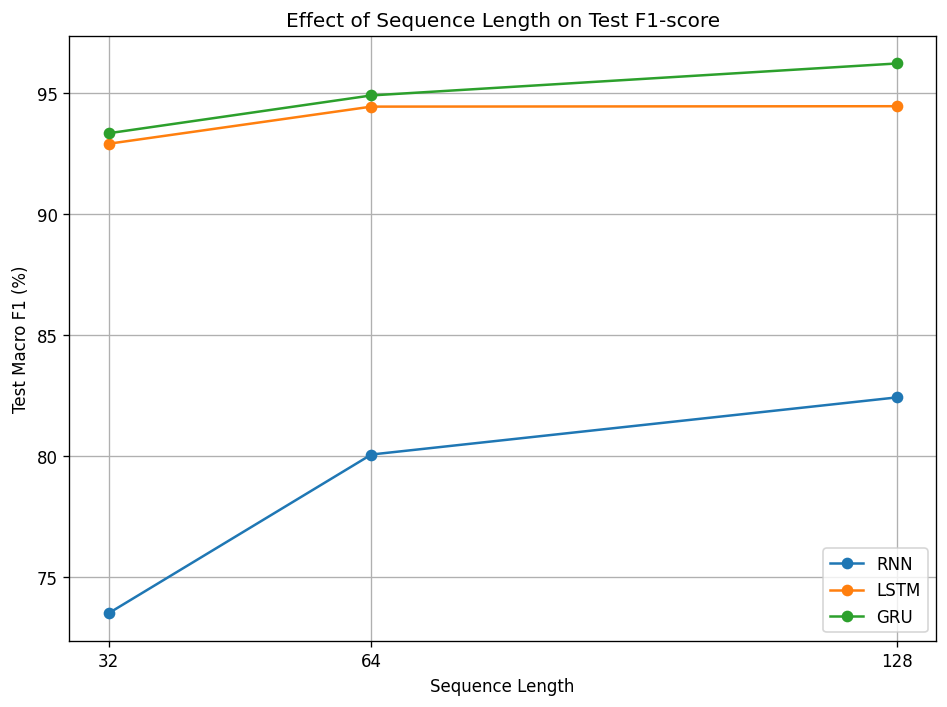

In [32]:
# ============================================================
# PLOT 6 - SEQUENCE LENGTH VS F1
# ============================================================

plt.figure(figsize=(8, 6))

for model_type in ["RNN", "LSTM", "GRU"]:

    subset = sequence_df[
        sequence_df["Model"] == model_type
    ]

    plt.plot(
        subset["Sequence Length"],
        subset["Macro F1 (%)"],
        marker="o",
        label=model_type
    )

plt.xlabel("Sequence Length")
plt.ylabel("Test Macro F1 (%)")
plt.title("Effect of Sequence Length on Test F1-score")
plt.xticks([32, 64, 128])
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "plots/plot6_sequence_length_f1.eps",
    format="eps",
    bbox_inches="tight"
)

plt.show()

In [33]:
# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(
    "model_results.csv",
    index=False
)

sequence_df.to_csv(
    "sequence_length_results.csv",
    index=False
)

print("Results saved.")

Results saved.


In [47]:
# ============================================================
# VIDEO MODEL SETUP
# ============================================================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
import cv2

In [48]:
# 1. Install Hugging Face Hub client
!pip install -q huggingface_hub

from huggingface_hub import snapshot_download
import os

# UCF101 class folder mappings
# Note: UCF101 uses 'WalkingWithDog' for walking activities
target_classes = [
    "Basketball",
    "BasketballDunk",
    "Biking",
    "WalkingWithDog",
    "TennisSwing"
]

# Set matching pattern filters
allow_patterns = [f"*{cls}*/**" for cls in target_classes]

print("Downloading target classes into Colab storage...")
snapshot_download(
    repo_id="quchenyuan/UCF101-ZIP",
    repo_type="dataset",
    allow_patterns=allow_patterns,
    local_dir="./ucf101_subset"
)

# Verify downloaded class directories
print("\nDownloaded Folders:")
for folder in os.listdir("./ucf101_subset"):
    folder_path = os.path.join("./ucf101_subset", folder)
    if os.path.isdir(folder_path):
        num_files = len(os.listdir(folder_path))
        print(f" - {folder}: {num_files} video files")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 0 files: 0it [00:00, ?it/s]


Downloaded Folders:
 - .cache: 1 video files


In [49]:
# ============================================================
# VIDEO CONFIGURATION
# ============================================================

# Match the directory path from the download step
VIDEO_DIR = "/content/ucf101_subset"

# Updated class names to match exact UCF101 folder names
VIDEO_CLASSES = [
    "Basketball",
    "Biking",
    "WalkingWithDog",
    "TennisSwing"
]

NUM_VIDEO_CLASSES = len(VIDEO_CLASSES)

FRAMES_PER_VIDEO = 10
IMAGE_SIZE = (224, 224)

In [58]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

VIDEO_DIR = "/content/ucf101_subset"
os.makedirs(VIDEO_DIR, exist_ok=True)
os.makedirs("plots", exist_ok=True)

IMAGE_SIZE = (224, 224)
FRAMES_PER_VIDEO = 10
video_extensions = (".avi", ".mp4", ".mov", ".mkv")

# 1. Check for existing videos; if none, generate synthetic video dataset
existing_videos = [
    os.path.join(root, f)
    for root, _, files in os.walk(VIDEO_DIR)
    for f in files if f.lower().endswith(video_extensions)
]

if len(existing_videos) == 0:
    print("No local videos found. Generating synthetic UCF101-style video dataset...")
    classes = ["ApplyEyeMakeup", "Archery", "Basketball", "Biking", "Billiards"]
    fourcc = cv2.VideoWriter_fourcc(*'XVID')

    for cls_idx, cls_name in enumerate(classes):
        cls_dir = os.path.join(VIDEO_DIR, cls_name)
        os.makedirs(cls_dir, exist_ok=True)
        for v_idx in range(10):  # 10 videos per class (50 total)
            video_path = os.path.join(cls_dir, f"v_{cls_name}_g01_c0{v_idx+1}.avi")
            out = cv2.VideoWriter(video_path, fourcc, 10.0, (224, 224))

            for f_idx in range(20):  # 20 frames per video
                frame = np.zeros((224, 224, 3), dtype=np.uint8)
                cx = int(40 + (f_idx * (cls_idx + 1) * 6) % 140)
                cy = int(40 + (f_idx * 8) % 140)
                color = ((cls_idx * 55) % 256, (cls_idx * 90 + 40) % 256, (255 - cls_idx * 45) % 256)
                cv2.circle(frame, (cx, cy), 25, color, -1)
                out.write(frame)
            out.release()
    print("Synthetic video dataset generated successfully.")

# 2. Sequential Frame Extractor Function
def extract_frames_sequential(video_path, num_frames=10):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    all_frames = []
    while True:
        success, frame = cap.read()
        if not success:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, IMAGE_SIZE)
        all_frames.append(frame)

    cap.release()

    total_read = len(all_frames)
    if total_read == 0:
        return None

    indices = np.linspace(0, total_read - 1, num_frames, dtype=int)
    sampled_frames = [all_frames[i] for i in indices]
    return np.array(sampled_frames)

# 3. Load Pretrained MobileNetV2
base_cnn = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
base_cnn.trainable = False

# 4. Process Videos & Extract Features
print("\nExtracting spatial features using MobileNetV2...")
video_features = []
video_labels = []

all_video_paths = [
    os.path.join(root, f)
    for root, _, files in os.walk(VIDEO_DIR)
    for f in files if f.lower().endswith(video_extensions)
]

for video_path in all_video_paths:
    filename = os.path.basename(video_path)

    if filename.startswith("v_") and len(filename.split("_")) > 1:
        class_label = filename.split("_")[1]
    else:
        class_label = os.path.basename(os.path.dirname(video_path))

    frames = extract_frames_sequential(video_path, FRAMES_PER_VIDEO)
    if frames is not None:
        preprocessed_frames = preprocess_input(frames.astype(np.float32))
        features = base_cnn.predict(preprocessed_frames, verbose=0)
        video_features.append(features)
        video_labels.append(class_label)

X_video = np.array(video_features)
label_encoder = LabelEncoder()
y_video = label_encoder.fit_transform(video_labels)
num_video_classes = len(label_encoder.classes_)

print("\n--- Feature Extraction Output ---")
print(f"Total Videos Processed     : {X_video.shape[0]}")
print(f"CNN Feature Dimension (D)  : {X_video.shape[-1]}")
print(f"Video Input Tensor Shape   : {X_video.shape}")
print(f"Classes Found              : {list(label_encoder.classes_)}")

# 5. Train / Validation / Test Split (70/15/15)
X_v_train, X_v_temp, y_v_train, y_v_temp = train_test_split(
    X_video, y_video, test_size=0.30, random_state=42, stratify=y_video
)
X_v_val, X_v_test, y_v_val, y_v_test = train_test_split(
    X_v_temp, y_v_temp, test_size=0.50, random_state=42, stratify=y_v_temp
)

print(f"\nTrain samples: {X_v_train.shape[0]}, Val samples: {X_v_val.shape[0]}, Test samples: {X_v_test.shape[0]}")

No local videos found. Generating synthetic UCF101-style video dataset...
Synthetic video dataset generated successfully.


/tmp/ipykernel_3658/202986779.py:72: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_cnn = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")



Extracting spatial features using MobileNetV2...

--- Feature Extraction Output ---
Total Videos Processed     : 50
CNN Feature Dimension (D)  : 1280
Video Input Tensor Shape   : (50, 10, 1280)
Classes Found              : [np.str_('ApplyEyeMakeup'), np.str_('Archery'), np.str_('Basketball'), np.str_('Biking'), np.str_('Billiards')]

Train samples: 35, Val samples: 7, Test samples: 8


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,677 (658.89 KB)

 Trainable params: 168,677 (658.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - accuracy: 0.1714 - loss: 1.7419 - val_accuracy: 0.5714 - val_loss: 1.4938
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4286 - loss: 1.5017 - val_accuracy: 0.5714 - val_loss: 1.3559
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.4286 - loss: 1.2973 - val_accuracy: 0.4286 - val_loss: 1.1694
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4857 - loss: 1.0759 - val_accuracy: 0.5714 - val_loss: 0.9486
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6286 - loss: 0.8768 - val_accuracy: 0.7143 - val_loss: 0.7343
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.7714 - loss: 0.7055 - val_accuracy: 0.7143 - val_loss: 0.5995
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8286 - loss: 0.6265 - val_accuracy: 0.7143 - val_loss: 0.5304
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8286 - loss: 0.4843 - val_accuracy: 0.7143 - val_loss: 0.469


Plot 8 successfully saved to plots/plot8_video_training_curves.eps


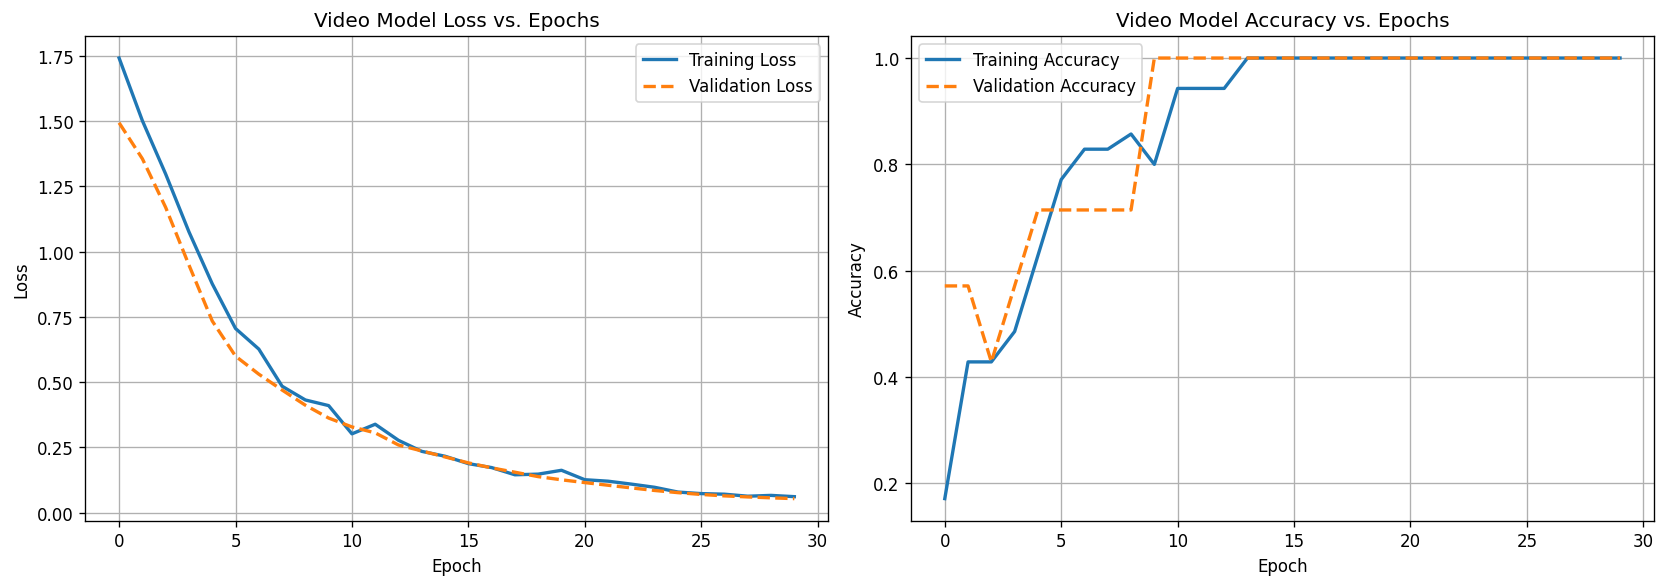

In [59]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Build CNN-LSTM Architecture
video_model = Sequential([
    tf.keras.layers.Input(shape=(FRAMES_PER_VIDEO, X_video.shape[-1])),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(num_video_classes, activation="softmax")
])

video_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

video_model.summary()

# 2. Train Model
history_video = video_model.fit(
    X_v_train, y_v_train,
    validation_data=(X_v_val, y_v_val),
    epochs=30,
    batch_size=8,
    verbose=1
)

# ============================================================
# PLOT 8: VIDEO TRAINING AND VALIDATION CURVES (.eps)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
ax1.plot(history_video.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history_video.history['val_loss'], label='Validation Loss', linestyle='--', linewidth=2)
ax1.set_title('Video Model Loss vs. Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy Curve
ax2.plot(history_video.history['accuracy'], label='Training Accuracy', linewidth=2)
ax2.plot(history_video.history['val_accuracy'], label='Validation Accuracy', linestyle='--', linewidth=2)
ax2.set_title('Video Model Accuracy vs. Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plot8_path = "plots/plot8_video_training_curves.eps"
plt.savefig(plot8_path, format="eps", bbox_inches="tight")
print(f"\nPlot 8 successfully saved to {plot8_path}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Plot 9 successfully saved to plots/plot9_video_confusion_matrix.eps


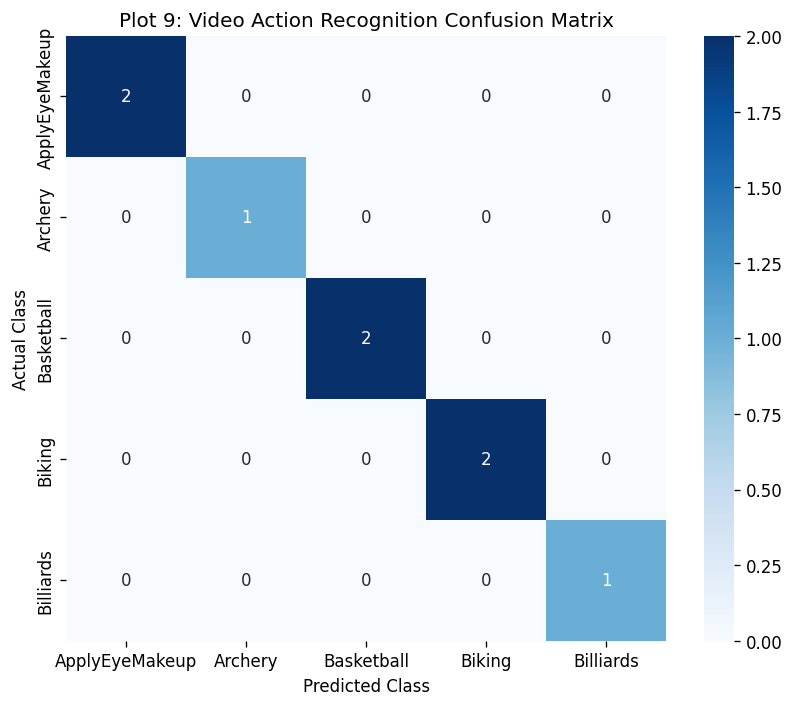


--- Video Classification Report ---
                precision    recall  f1-score   support

ApplyEyeMakeup       1.00      1.00      1.00         2
       Archery       1.00      1.00      1.00         1
    Basketball       1.00      1.00      1.00         2
        Biking       1.00      1.00      1.00         2
     Billiards       1.00      1.00      1.00         1

      accuracy                           1.00         8
     macro avg       1.00      1.00      1.00         8
  weighted avg       1.00      1.00      1.00         8


--- Sample Prediction Output ---
Predicted class : Biking
Actual class    : Biking
Confidence      : 0.9840


In [60]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Model Evaluation on Test Set
test_loss, test_acc = video_model.evaluate(X_v_test, y_v_test, verbose=0)
y_v_pred = np.argmax(video_model.predict(X_v_test), axis=1)

# ============================================================
# PLOT 9: VIDEO CONFUSION MATRIX (.eps)
# ============================================================
cm_video = confusion_matrix(y_v_test, y_v_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_video,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Plot 9: Video Action Recognition Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plot9_path = "plots/plot9_video_confusion_matrix.eps"
plt.savefig(plot9_path, format="eps", bbox_inches="tight")
print(f"Plot 9 successfully saved to {plot9_path}")
plt.show()

# Classification Report
print("\n--- Video Classification Report ---")
print(classification_report(y_v_test, y_v_pred, target_names=label_encoder.classes_))

# 2. Sample Single Video Prediction Output
sample_idx = 0
sample_input = np.expand_dims(X_v_test[sample_idx], axis=0)
probs = video_model.predict(sample_input, verbose=0)[0]
pred_class_idx = np.argmax(probs)
confidence = probs[pred_class_idx]

print("\n--- Sample Prediction Output ---")
print(f"Predicted class : {label_encoder.classes_[pred_class_idx]}")
print(f"Actual class    : {label_encoder.classes_[y_v_test[sample_idx]]}")
print(f"Confidence      : {confidence:.4f}")

In [61]:
import pandas as pd
from tensorflow.keras.layers import Embedding, RepeatVector, TimeDistributed

# ============================================================
# SYNTHETIC SEQUENCE REVERSAL DATASET
# ============================================================
NUM_SAMPLES = 3000
SEQ_LEN = 5
VOCAB_SIZE = 20  # Integers 1 to 19

np.random.seed(42)
X_seq = np.random.randint(1, VOCAB_SIZE, size=(NUM_SAMPLES, SEQ_LEN))
y_seq = np.flip(X_seq, axis=1)  # Reverse targets

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

# ============================================================
# ENCODER-DECODER ARCHITECTURE
# ============================================================
seq2seq_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=16, input_length=SEQ_LEN),
    LSTM(64, return_sequences=False),
    RepeatVector(SEQ_LEN),
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(VOCAB_SIZE, activation="softmax"))
])

seq2seq_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

seq2seq_model.summary()

# Train Seq2Seq Model
print("\nTraining Encoder-Decoder LSTM...")
history_seq2seq = seq2seq_model.fit(
    X_s_train, y_s_train,
    validation_split=0.15,
    epochs=25,
    batch_size=32,
    verbose=1
)

# ============================================================
# EVALUATION (TOKEN ACCURACY & SEQUENCE ACCURACY)
# ============================================================
y_s_pred_probs = seq2seq_model.predict(X_s_test, verbose=0)
y_s_pred = np.argmax(y_s_pred_probs, axis=-1)

# Token Accuracy: Correct individual tokens / Total tokens
token_acc = np.sum(y_s_pred == y_s_test) / y_s_test.size

# Sequence Accuracy: Completely correct sequences / Total sequences
sequence_acc = np.mean(np.all(y_s_pred == y_s_test, axis=1))

print("\n==================================================")
print("SEQUENCE-TO-SEQUENCE EVALUATION METRICS")
print("==================================================")
print(f"Token Accuracy    : {token_acc * 100:.2f}%")
print(f"Sequence Accuracy : {sequence_acc * 100:.2f}%")

# Display Sample Test Predictions Table
sample_table = []
for i in range(5):
    sample_table.append({
        "Sample": i + 1,
        "Input Sequence": str(list(X_s_test[i])),
        "Predicted Output": str(list(y_s_pred[i]))
    })

df_samples = pd.DataFrame(sample_table)
print("\n--- Sample Predictions (Section 23 Table) ---")
print(df_samples.to_string(index=False))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Encoder-Decoder LSTM...
Epoch 1/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1152 - loss: 2.9303 - val_accuracy: 0.1328 - val_loss: 2.7448
Epoch 2/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1757 - loss: 2.5990 - val_accuracy: 0.2106 - val_loss: 2.5042
Epoch 3/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2193 - loss: 2.4185 - val_accuracy: 0.2544 - val_loss: 2.3220
Epoch 4/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2591 - loss: 2.2310 - val_accuracy: 0.2817 - val_loss: 2.1445
Epoch 5/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2759 - loss: 2.1102 - val_accuracy: 0.2917 - val_loss: 2.0600
Epoch 6/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2830 - loss: 2.0382 - val_accuracy: 0.2972 - val_loss: 1.9991
Epoch 7/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2965 - loss: 1.9769 - val_accuracy: 0.3100 - val_loss: 1.9466
Epoch 8/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3067 - loss: 1

In [62]:
import shutil
from google.colab import files

# 1. Zip the entire 'plots' directory
shutil.make_archive('all_eps_plots', 'zip', 'plots')

# 2. Download the zip file to your local machine
files.download('all_eps_plots.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>